# KNN demo
K-Nearest Neighbor is a supervised ML algorithm with a target variable (y) depending on independent variables (X) used for prediction.
In this algorithm, the entire training dataset is stored. When a prediction is required, the k-most similar records to a new record from the training dataset are then located. From these neighbors, a summarized prediction is made.

### Load data

We will use the digit dataset in this tutorial. Each value in the `X` (features) represent the pixel density.

Total dataset shape: (1797, 64)
Training features shape: (1437, 64)
Testing features shape: (360, 64)


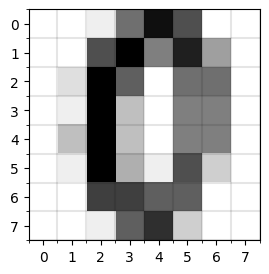

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Load the dataset
digits = load_digits()

# 2. Extract features (X) and target labels (y)
# X contains the flattened 8x8 images (64 features per sample)
# y contains the actual true digit (0 through 9)
X = digits.data
y = digits.target

# 3. Split into training and testing sets 
# Using a fixed random_state ensures your comparisons are fair and reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Optional: Print the shapes to verify
print(f"Total dataset shape: {X.shape}")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

plt.figure(1, figsize=(3, 3))
plt.imshow(digits.images[10], cmap=plt.cm.gray_r, interpolation="nearest")

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(1))

# By default, ticks center on pixels, so we shift them to the edges (-0.5)
plt.gca().xaxis.set_ticks(np.arange(-0.5, 8, 1), minor=True)
plt.gca().yaxis.set_ticks(np.arange(-0.5, 8, 1), minor=True)
plt.gca().grid(which='minor', color='k', linestyle='-', linewidth=1.5, alpha=0.1)


# plt.scatter(4, 4, color='red', marker=',', s=60, facecolors='none', edgecolors='red', linewidths=2)

plt.show()



### KNN classifier function
This k-Nearest Neighbors tutorial is broken down into 3 parts:

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*CVcFTGsIZ-sj_Z_CY5X0Ew.png" width=50%>

#### Step 1: Calculate Euclidean Distance.
- We can calculate the straight line distance between two vectors using the Euclidean distance measure. It is calculated as the square root of the sum of the squared differences between the two vectors.G iven two points $P$ and $Q$ in an $n$-dimensional space, the Euclidean distance $d$ is:

$$d(P, Q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$


- To locate the neighbors for a new piece of data within a dataset we must first calculate the distance between each record in the dataset to the new piece of data (note in the image not all arrows are shown)

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*0ObiRFulLMuXQ5aj6dO7BQ.png" width=50%>

#### Step 2: Get Nearest Neighbors.
- Neighbors for a new piece of data in the dataset are the k closest instances, as defined by our distance measure.
- Once distances are calculated, we must sort all of the records in the training dataset by their distance to the new data. We can then select the top k to return as the most similar neighbors.

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*El2DdaYNYaBficIL7EXwxg.png" width=50%>

#### Step 3: Make Predictions.
- The most similar neighbors collected from the training dataset is used to make predictions.
- `np.unique` is used to find the corresponding counts of each unique label type
- `np.argmax` is used to find the indices of the maximum values

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*TyqUebB-B9MN-XhcKmVGWA.png" width=50%>


In [2]:
import numpy as np

def KNNClassify(x_test_sample, X_train, Y_train, k=8): 
    # x_test_sample is the 1D array of 1 digit (e.g., 64 or 784 pixels)
    # X_train is the 2D array of all training digits
    # Y_train is the 1D array of all training labels

    ## Step 1: Calculate Distances
    distance_list = []

    # For every example in the training set, calculate euclidean distance
    for i in range(len(X_train)):
        point = X_train[i]
        
        # Vectorized Euclidean distance calculation. 
        # This automatically subtracts all features, squares them, sums them, and square-roots the result.
        distance = np.sqrt(np.sum((point - x_test_sample)**2))

        # Place this calculated distance into the list
        distance_list.append((distance, i))

    ## Step 2: Find K-Nearest Neighbors
    # Sort distances in ascending order by distance
    sorted_distance_list = sorted(distance_list)

    # The k nearest neighbours are the top k points in the sorted list
    neighbours = sorted_distance_list[0:k]

    # Get index of the minimum distances
    neighbours_index = []
    for distance, idx in neighbours:
        neighbours_index.append(idx)

    ## Step 3: Vote for the Majority Label
    # Check which label has majority
    output = Y_train[neighbours_index]
    
    # Get unique labels and their counts among the neighbors
    values, counts = np.unique(output, return_counts=True)

    # Return the label with the highest count
    max_idx = np.argmax(counts)
    return values[max_idx]

### Running the classifier to predict the labels for the testing set

In [10]:
#getting predicted values using our algorithm
pred=[]
for x_test_pt in X_test:
    pred.append(KNNClassify(x_test_pt, X_train, y_train))

In [12]:
def accuracy(predictions , y_test):
    count = 0
    for i in range(len(predictions)):
        if predictions[i] == y_test[i]:
            count +=1
    return count/len(predictions)


#compare the predictions against the y_tests (true labels）
acc = accuracy(pred, y_test)
print("Accuracy =", acc)

Accuracy = 0.9861111111111112


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
sk_knn = KNeighborsClassifier(n_neighbors=8)

# 4. Train the model
sk_knn.fit(X_train, y_train)

# 5. Make predictions
predictions = sk_knn.predict(X_test)


# 6. Evaluate the performance
accuracy = accuracy_score(y_test, predictions)

print("Accuracy =", accuracy)

Accuracy = 0.9861111111111112


### Exercise
1. Alice wants to use KNN to classify cat and dog images, which have millions of training images. She wants to distribute this model on the internet. Is this feasible? Why or why not? (hint: think about the size of the trained model)  


Reference
1. https://machinelearningmastery.com/tutorial-to-implement-k-nearest-neighbors-in-python-from-scratch/
2. https://medium.com/analytics-vidhya/k-nn-from-scratch-212dcff13eb3
3. https://towardsdatascience.com/create-your-own-k-nearest-neighbors-algorithm-in-python-eb7093fc6339

**accompanying slides:**
https://docs.google.com/presentation/d/1jNR_1fJYOuR8qoLcwh7M07zZB2ObDOufiHQtOVJKuNU/edit?usp=sharing